In [1]:
import cebra
from toy_data_flow import *
import torch

## Generate Data

In [11]:
gen = DoubleCircles()
dataTrain = gen.generate(n=100,T=1,dt=0.001,sigma=1.5)
dataTest = gen.generate(n=20,T=1,dt=0.001,sigma=1.5)
p = projection(origDim=2,newDim=3,projType='sigmoid',temp=3)

projectedTrain,projectedTest = [p.project(traj) for traj in dataTrain], [p.project(traj) for traj in dataTest]
labelsTrain = [(ii +1)*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTrain)]
labelsTest = [(ii+1 + labelsTrain[-1])*np.ones((len(t),),dtype=np.int16) for ii,t in enumerate(projectedTest)]

In [24]:
params_grid = dict(
    output_dimension = [2],
    learning_rate = [1e-3,1e-4,1e-4],
    time_offsets = [2,5,10,20,50,100],
    max_iterations = 1000,
    temperature_mode = "auto",
    verbose = False,
    batch_size=256)

datasets = {'dataset1': np.vstack(dataTrain)}

grid_search = cebra.grid_search.GridSearch()
grid_search.fit_models(datasets=datasets, params=params_grid, models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")

In [25]:
df_results = grid_search.get_df_results(models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")
best_model, best_model_name = grid_search.get_best_model(dataset_name="dataset1", models_dir="/home/miles/isilon/All_Staff/miles/comparison_models/cebra_comparisons")

In [26]:
df_results.head()

,learning_rate,time_offsets,loss,dataset_name
0,0.001,2,4.171534,dataset1
1,0.001,5,4.190322,dataset1
2,0.001,10,4.188584,dataset1
3,0.001,20,4.289980,dataset1
4,0.001,50,4.488189,dataset1


<Axes: title={'center': 'Embedding'}>

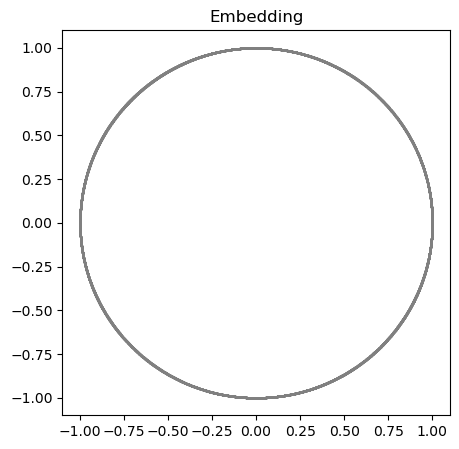

In [27]:
embedding = best_model.transform(np.vstack(dataTrain))
cebra.plot_embedding(embedding)